In [2]:
import sys
import os

# Add the folder and subfolder to the system path
sys.path.append(os.path.abspath(os.path.join('../../')))

# Now you can import your module
# from your_module import your_function

# Inport data from geopandas

In [3]:
import numpy as np
import pandas as pd

parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../../data/"
year = "2020"
df = pd.read_csv(parent_dir + f'albopictus_presence_absence_ecdc_copernicus_{year}.zip')
#df_suitable = df[df['Suitable'] == 1]  # Select only the suitable records
df_suitable = df
df_Presence_Absence = (df_suitable[(df_suitable["presence_numeric"] == 1) | (df_suitable["presence_numeric"] == 0)]).copy()
df_Presence_Absence["NUTS3_Code"] = df_Presence_Absence["LocationCode"]

In [4]:
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['presence_numeric'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)

# Check data and remove points set as absence close to points set as presence

<Axes: >

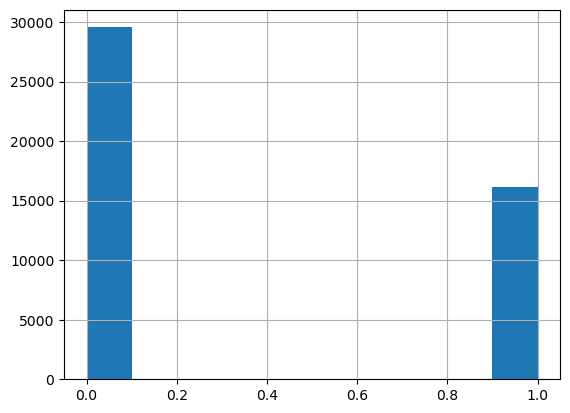

In [5]:
import matplotlib.pyplot as plt
df_Presence_Absence["Presence_Absence"].hist()

In [6]:
import geopandas as gpd

df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['longitude'], df_Presence_Absence['latitude']))

<Axes: >

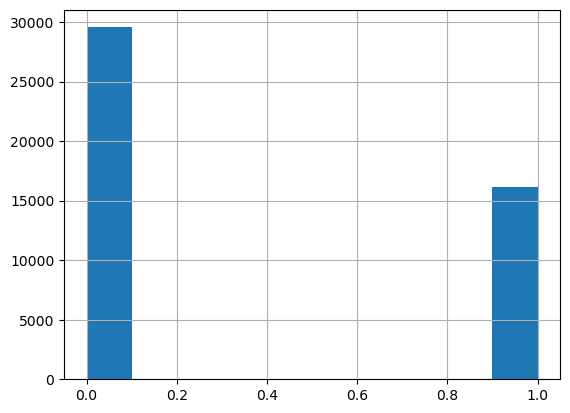

In [7]:
df_Presence_Absence = df_gdf.copy()

df_Presence_Absence["Presence_Absence"].hist()

In [8]:
import AIedes.data_loader.classificator_data_loader
import importlib

from AIedes.data_loader.classificator_data_loader import normalize_temperature_df, normalize_precipitation_df

df_Presence_Absence = normalize_temperature_df(df_Presence_Absence)
df_Presence_Absence = normalize_precipitation_df(df_Presence_Absence)

temp_cols ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C']
Temperature columns normalized with mean and std.
precip_cols ['precip_Jan_mm', 'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm', 'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm', 'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
Precipitation columns normalized with mean and std.


In [9]:
features = ['temp_Jan_C', 'temp_Feb_C', 'temp_Mar_C', 'temp_Apr_C', 
            'temp_May_C', 'temp_Jun_C', 'temp_Jul_C', 'temp_Aug_C', 
            'temp_Sep_C', 'temp_Oct_C', 'temp_Nov_C', 'temp_Dec_C', 'precip_Jan_mm',
            'precip_Feb_mm', 'precip_Mar_mm', 'precip_Apr_mm',
            'precip_May_mm', 'precip_Jun_mm', 'precip_Jul_mm', 'precip_Aug_mm',
            'precip_Sep_mm', 'precip_Oct_mm', 'precip_Nov_mm', 'precip_Dec_mm']
datas = {}
df_years = {}

data = df_Presence_Absence[features + ["Presence_Absence"]].to_numpy()


In [10]:
import importlib
import torch
# set threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
torch.set_num_threads(4)
# set number of cpu threads to 1 to avoid issues with multiprocessing in Jupyter notebooks
#torch.set_num_interop_threads(4)

In [11]:
import importlib
from locale import normalize
from AIedes.data_loader.classificator_data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 1024
learning_rate = 0.002
random_seed = 42

train_loaders = {}
test_loaders = {}
train_loader_order, test_loader_order, input_size_order, _ = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)



/home/biazzin/git/AIedes/src/AIedes/data_loader/classificator_data_loader.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


# Function like the paper

In [12]:
import pandas as pd
import pickle
from AIedes.train.classificator_train    import run_model
from AIedes.evaluation.classificator_evaluate import evaluate_model_nuts3, evaluate_model

# read all the result and models files that have "temp_tp" in the name
# list in the current directory that have "temp_tp" in the name
import glob
results_files = glob.glob("../res/results_and_models*temp_tp.pkl")
print("Results files found:", results_files)
res_df = []
for name_file in results_files:
    print("Loading file:", name_file)
    with open(name_file, 'rb') as f:
        results = pickle.load(f)
    #print("Results loaded:", results)
    res_df.append(results)
res_df = pd.concat(res_df, ignore_index=True)
res_df

Results files found: ['../res/results_and_models_2020_[]_temp_tp.pkl', '../res/results_and_models_2020_[10, 10, 10]_temp_tp.pkl', '../res/results_and_models_2020_[10, 10]_temp_tp.pkl', '../res/results_and_models_2020_[10]_temp_tp.pkl', '../res/results_and_models_2020_[20, 20, 20]_temp_tp.pkl', '../res/results_and_models_2020_[20, 20]_temp_tp.pkl', '../res/results_and_models_2020_[20]_temp_tp.pkl', '../res/results_and_models_2020_[30, 30, 30]_temp_tp.pkl', '../res/results_and_models_2020_[30, 30]_temp_tp.pkl', '../res/results_and_models_2020_[30]_temp_tp.pkl', '../res/results_and_models_2020_[40, 40, 40]_temp_tp.pkl', '../res/results_and_models_2020_[40, 40]_temp_tp.pkl', '../res/results_and_models_2020_[50, 50, 50]_temp_tp.pkl', '../res/results_and_models_2020_[50, 50]_temp_tp.pkl']
Loading file: ../res/results_and_models_2020_[]_temp_tp.pkl
Loading file: ../res/results_and_models_2020_[10, 10, 10]_temp_tp.pkl
Loading file: ../res/results_and_models_2020_[10, 10]_temp_tp.pkl
Loading fi

,hidden_layers,ACC_test_list,TPR_test_list,TNR_test_list,FPR_test_list,FNR_test_list,MEAN_fold,MEAN_ACC_test,MEAN_TPR_test,MEAN_TNR_test,...,type,num_params,num_epochs,test_ratio,val_ratio,learning_rate,random_seed,input_variables,input_size,model
0,[],"[90.15855658829962, 90.41006014215418, 89.7648...","[0.8669965975873801, 0.8669965975873801, 0.861...","[0.9205006765899865, 0.9243910690121786, 0.917...","[0.07949932341001353, 0.07560893098782138, 0.0...","[0.13300340241261985, 0.13300340241261985, 0.1...",3.0,89.913382,0.860801,0.920095,...,NN,25,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
1,"[10, 10, 10]","[95.1776927282668, 95.8337889557135, 95.921268...","[0.9350448499845345, 0.9455613980822766, 0.957...","[0.9609269282814614, 0.9653247631935047, 0.960...","[0.03907307171853856, 0.034675236806495265, 0....","[0.06495515001546551, 0.05443860191772348, 0.0...",3.0,95.870879,0.951435,0.962686,...,NN,481,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
2,"[10, 10]","[95.03553854565337, 96.12903225806451, 95.0246...","[0.9486545004639654, 0.9467986390349521, 0.924...","[0.9512855209742895, 0.9692151556156969, 0.964...","[0.04871447902571042, 0.030784844384303112, 0....","[0.05134549953603464, 0.05320136096504794, 0.0...",3.0,95.468471,0.944507,0.960250,...,NN,371,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
3,[10],"[95.46200109349371, 94.08419901585566, 93.2312...","[0.9461800185586143, 0.9254562326012991, 0.920...","[0.9592354533152909, 0.949255751014885, 0.9385...","[0.040764546684709066, 0.05074424898511502, 0....","[0.05381998144138571, 0.0745437673987009, 0.07...",3.0,94.202149,0.932875,0.947023,...,NN,261,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
4,"[20, 20, 20]","[96.81793329688354, 97.64898851831602, 97.1350...","[0.9774203526136716, 0.9768017321373338, 0.980...","[0.963125845737483, 0.976319350473613, 0.96650...","[0.03687415426251692, 0.02368064952638701, 0.0...","[0.022579647386328488, 0.023198267862666256, 0...",3.0,97.279318,0.975563,0.971279,...,NN,1361,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
5,"[20, 20]","[97.255330781848, 97.255330781848, 97.12411153...","[0.9678317352304361, 0.968141045468605, 0.9644...","[0.9751353179972937, 0.9749661705006766, 0.974...","[0.02486468200270636, 0.02503382949932341, 0.0...","[0.03216826476956387, 0.03185895453139499, 0.0...",3.0,97.071547,0.962385,0.975271,...,NN,941,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
6,[20],"[95.80098414434117, 94.87151448879169, 96.1180...","[0.9353541602227033, 0.9403031240334055, 0.957...","[0.9703991880920162, 0.9533152909336942, 0.963...","[0.029600811907983762, 0.04668470906630582, 0....","[0.06464583977729663, 0.059696875966594495, 0....",3.0,95.536246,0.947167,0.959844,...,NN,521,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
7,"[30, 30, 30]","[97.71459814106069, 97.26626571897212, 97.9770...","[0.9508196721311475, 0.9452520878441076, 0.965...","[0.9915426251691475, 0.9876522327469553, 0.987...","[0.008457374830852503, 0.012347767253044655, 0...","[0.04918032786885246, 0.05474791215589236, 0.0...",3.0,97.627068,0.955333,0.987720,...,NN,2641,500,0.15,0.0,0.002,42,"[temp_Jan_C, temp_Feb_C, temp_Mar_C, temp_Apr_...",24,[AIedesClassificator(\n (layers): ModuleList(...
8,"[30, 30]","[97.38655002733735, 97.50683433570256, 97.3865...","[0.9582431178472007, 0.9703062171357872, 0.984...","[0.9824086603518268, 0.9776725304465493, 0.967...","[0.017591339648173207, 0.022327469553450607, 0...","[

In [13]:
res_df["CSI_test"] = res_df.apply(
    lambda row: row["MEAN_TPR_test"] / (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) if (row["MEAN_TPR_test"] + row["MEAN_FNR_test"] + row["MEAN_FPR_test"]) > 0 else 0,
    axis=1
)

In [14]:
import torch

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)

In [15]:
res_df.hidden_layers = res_df.hidden_layers.apply(lambda x: str(x))

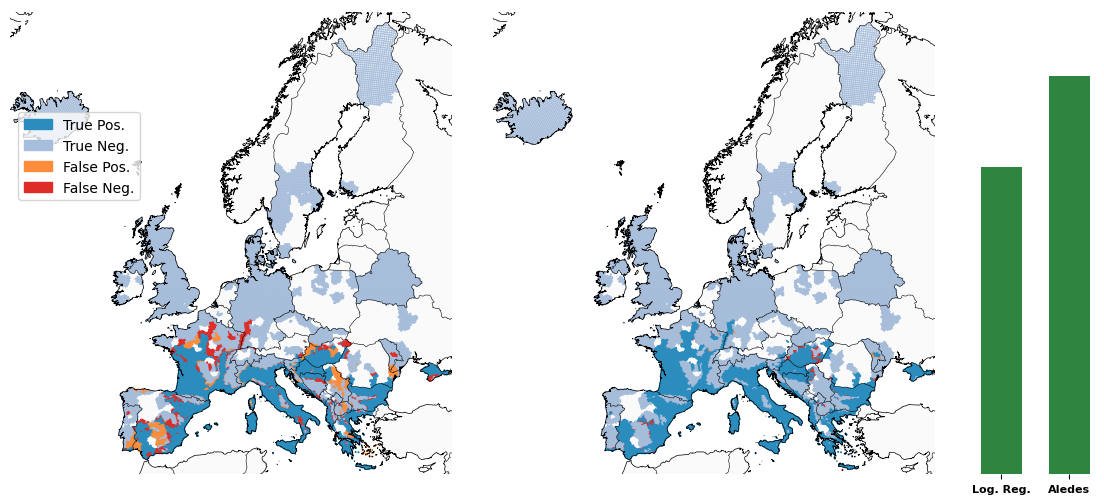

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np

# Prepare GeoDataFrame
df_Presence_Absence = gpd.GeoDataFrame(
    df_Presence_Absence.copy(), 
    geometry='geometry', 
    crs='EPSG:4326'
)

# Define categories and colors
categories = ['True Pos.', 'True Neg.', 'False Pos.', 'False Neg.']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
colormap = ListedColormap(colors)

# Calculate common extent for both maps
minx, miny, maxx, maxy = df_Presence_Absence.total_bounds
pad = 0.5
extent = [minx - pad, maxx + pad, miny - pad, maxy + pad]

# Create figure with two maps and a bar chart
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[4, 4, 1], wspace=0.01)
axes = [fig.add_subplot(gs[0, i], projection=ccrs.Mercator()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

# Configure map axes
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_anchor('W')
    ax.patch.set_visible(False)
    ax.coastlines('10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.1)
    ax.spines['geo'].set_visible(False)
    ax.set_facecolor('none')


def pred_str(true, pred):
    """Classify prediction result"""
    if true == 1 and pred == 1:
        return 'True Pos.'
    elif true == 0 and pred == 0:
        return 'True Neg.'
    elif true == 1 and pred == 0:
        return 'False Neg.'
    else:
        return 'False Pos.'


def plot_predictions(df, ax, markersize=2, alpha=0.8):
    """Plot prediction results on map"""
    df_valid = df[df.geometry.is_valid].copy()
    
    # Map categories to numeric values
    cat_to_idx = {c: i for i, c in enumerate(categories)}
    cvals = df_valid['results'].map(cat_to_idx).to_numpy()
    
    # Plot with lat/lon coordinates
    ax.scatter(
        df_valid.geometry.x.to_numpy(),
        df_valid.geometry.y.to_numpy(),
        c=cvals, 
        s=markersize, 
        cmap=colormap, 
        alpha=alpha,
        edgecolors='none', 
        transform=ccrs.PlateCarree()
    )


# Model 1: Logistic Regression (no hidden layers)
model_info = res_df[res_df["hidden_layers"] == "[]"]
net = model_info["model"].values[0][0]

df_lr = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_lr["predicted_estim_risk"] = compute_suitability_index(net, test_loader_order).numpy()
df_lr["predicted"] = df_lr["predicted_estim_risk"] > 0.5
df_lr["results"] = df_lr.apply(
    lambda x: pred_str(x["Presence_Absence"], x["predicted"]), 
    axis=1
)

plot_predictions(df_lr, axes[0])
acc_lr = model_info["MEAN_ACC_test"].values[0]

axes[0].text(
    0.02, 0.94, "Logistic regression",
    transform=axes[0].transAxes,
    fontsize=16, fontweight='bold', 
    va='bottom', ha='left', color='white'
)

# Model 2: Neural Network with hidden layers
model_info = res_df[res_df["hidden_layers"] == "[50, 50, 50]"]
net = model_info["model"].values[0][0]

df_nn = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_nn["predicted_estim_risk"] = compute_suitability_index(net, test_loader_order).numpy()
df_nn["predicted"] = df_nn["predicted_estim_risk"] > 0.5
df_nn["results"] = df_nn.apply(
    lambda x: pred_str(x["Presence_Absence"], x["predicted"]), 
    axis=1
)

plot_predictions(df_nn, axes[1])
acc_nn = model_info["MEAN_ACC_test"].values[0]

axes[1].text(
    0.02, 0.94, "AIedes",
    transform=axes[1].transAxes,
    fontsize=16, fontweight='bold', 
    va='bottom', ha='left', color='white'
)

# Accuracy bar chart
accuracy_values = np.array([acc_lr, acc_nn]) / 100
x_labels = ['Log. Reg.', 'AIedes']
x = np.arange(len(x_labels))

ax_bar.bar(x, accuracy_values, width=0.6, color="#2E8540")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(x_labels, fontsize=8, fontweight='bold')
ax_bar.set_ylim(0.60, 1.05)
ax_bar.set_yticks([])
ax_bar.set_title(
    "Accuracy", 
    fontsize=16, fontweight='bold', 
    loc='center', y=0.95, color='white'
)
ax_bar.set_facecolor('none')
for spine in ax_bar.spines.values():
    spine.set_visible(False)

# Add accuracy text labels on bars
for i, v in enumerate(accuracy_values):
    ax_bar.text(
        i, v + 0.01, f'{v:.1%}', 
        ha='center', va='bottom', 
        fontweight='bold', color='white'
    )

# Add legend
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(
    handles=patches, 
    bbox_to_anchor=(0.126, 0.64), 
    loc='center left', 
    frameon=True, 
    fontsize=10
)

# Save with transparent background
fig.patch.set_alpha(0)
fig.savefig(
    "./comparison_lr_nn_poster.png", 
    dpi=400, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

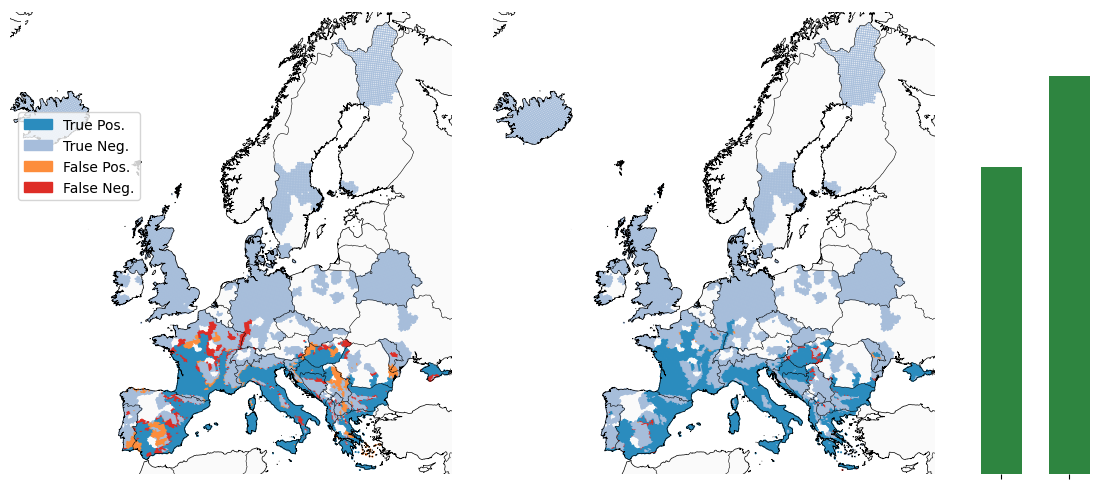

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt
#import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np

df_Presence_Absence = gpd.GeoDataFrame(df_Presence_Absence.copy(), geometry='geometry', crs='EPSG:4326')
#minx, miny, maxx, maxy = df_Presence_Absence.total_bounds

categories = ['True Pos.', 'True Neg.', 'False Pos.', 'False Neg.']
colors = ['#195589', '#4A99D2', '#C73E1D', '#8B0000']  # Dark red and maroon for false cases
colors = ['#195589', '#4A99D2', '#7B2D8E', '#4A1A4A']  # Purple tones for false cases
colors = ['#195589', '#4A99D2', '#228B22', '#B8860B']  # Forest green and dark goldenrod
colors = ['#195589', '#4A99D2', '#D19429', '#545359']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']


# 1) create axes with a real map projection
# 1) Compute ONE common geographic extent and reuse it
minx, miny, maxx, maxy = df_Presence_Absence.total_bounds
pad = 0.5
extent = [minx - pad, maxx + pad, miny - pad, maxy + pad]

fig = plt.figure(figsize=(14, 6))
gs  = fig.add_gridspec(1, 3, width_ratios=[4, 4, 1], wspace=0.01)  # tighter
axes = [fig.add_subplot(gs[0, i], projection=ccrs.Mercator()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

for ax in axes:
    # same geographic extent on both:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # don't force equal aspect
    # ax.set_aspect('auto')  # optional
    # anchor the map to the left inside each subplot slot:
    ax.set_anchor('W')
    # optional: hide outline to avoid perceived padding box
    ax.patch.set_visible(False)  # hide subplot background patch
    # features...
    ax.coastlines('10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.1)

def plot_map(df_, ax, markersize=20, marker='.', alpha=1, title=None):
    colormap = ListedColormap(colors)
    df_sampled = df_.copy()
    df_sampled = df_sampled[df_sampled.geometry.is_valid]
    minx, miny, maxx, maxy = df_sampled.total_bounds

    # compute categories (as you already do) ...

    # set geographic extent (in degrees)
    pad = 0.5
    ax.set_extent([minx-pad, maxx+pad, miny-pad, maxy+pad], crs=ccrs.PlateCarree())

    # features
    #ax.coastlines('10m', linewidth=0.5)
    #ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    #ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.1)
    ax.set_facecolor('none')

    # map categories to 0..3 to use your ListedColormap
    cat_to_idx = {c:i for i, c in enumerate(categories)}
    cvals = df_sampled['results'].map(cat_to_idx).to_numpy()
    ax.spines['geo'].set_visible(False)

    # PLOT with transform telling Cartopy your data are in lon/lat
    ax.scatter(
        df_sampled.geometry.x.to_numpy(),
        df_sampled.geometry.y.to_numpy(),
        c=cvals, s=markersize, cmap=colormap, alpha=alpha,
        edgecolors='none', transform=ccrs.PlateCarree()
    )

    return ax

all_df_res = []
def pred_str(true, pred):
    return 'True Pos.' if true == 1 and pred == 1 else 'True Neg.' if true == 0 and pred == 0 else 'False Neg.' if true == 1 and pred == 0 else 'False Pos.'

accs = {}
model_info = res_df[res_df["hidden_layers"] == "[]"]
net_ = model_info["model"].values[0][0]
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5
df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)
plot_map(df_temp, axes[0], markersize=2, marker='.', alpha=0.8, title='No Hidden Layers \n(Logistic Regression)')
accs["[]"] = model_info["MEAN_ACC_test"].values[0]

model_info = res_df[res_df["hidden_layers"] == "[50, 50, 50]"]
net_ = model_info["model"].values[0][0]
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5
df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)
plot_map(df_temp, axes[1], markersize=2, marker='.', alpha=0.8, title='[50,50,50] Hidden Layers \n(Neural Network)')
accs["[50, 50, 50]"] = model_info["MEAN_ACC_test"].values[0]

# Bar plot for accuracy, TPR, TNR, and CSI
x_labels = ['Log. Reg.', 'Largest NN']
x = np.arange(len(x_labels))  # the label locations
width = 0.2  # the width of the bars

# Values for each metric
# Only accuracy
accuracy_values = np.array(list(accs.values())) / 100
x_labels = ['Log. Reg.', 'AIedes']
x = np.arange(len(x_labels))

# Clear previous bars (if needed)
ax_bar.clear()

# Plot full-width bars
ax_bar.bar(x, accuracy_values, width=0.6, color="#2E8540", label='Accuracy')

# Formatting
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(0.60, 1.05)
#ax_bar.set_ylabel('Accuracy')
ax_bar.set_title("Accuracy", fontsize=16, fontweight='bold', loc='center', y=0.95, color='white')
for spine in ax_bar.spines.values():
    spine.set_visible(False)

# Add accuracy values as text on bars
for i, v in enumerate(accuracy_values):
    ax_bar.text(i, v + 0.01, f'{v:.1%}', ha='center', va='bottom', fontweight='bold', color='white')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(x_labels, fontsize=8, color='white', fontweight='bold')
ax_bar.set_yticks([])
ax_bar.set_yticklabels([])
ax_bar.set_xlabel('Model Type', fontsize=8, color='white', fontweight='bold')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(x_labels, fontsize=8, fontweight='bold')
ax_bar.set_yticks([])
ax_bar.set_yticklabels([])
# remove x-label
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.set_xlabel('', fontsize=12)

# After plotting both maps and the bar:
import matplotlib.patches as mpatches
#categories = ['True Pos.', 'True Neg.', 'False Pos.', 'False Neg.']
#colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(handles=patches, bbox_to_anchor=(.126, 0.64), loc='center left', frameon=True, fontsize=10)

# Panel "a"
axes[0].text(
    0.02, 0.94, "Logistic regression",
    transform=axes[0].transAxes,
    fontsize=16, fontweight='bold', va='bottom', ha='left',
    color='white',
    #bbox=dict(facecolor='none', alpha=0.8, edgecolor='black', pad=5)
)

# Panel "b"
axes[1].text(
    0.02, 0.94, "AIedes",
    transform=axes[1].transAxes,
    fontsize=16, fontweight='bold', va='bottom', ha='left',
    color='white',
)

# Use tight_layout instead of show() for better spacing
#plt.tight_layout()
fig.patch.set_alpha(0)     # transparent figure background
ax_bar.set_facecolor('none')  # Make bar plot background transparent
for spine in ax.spines.values():
    spine.set_visible(False)

fig.savefig(f"./comparison_lr_nn_poster.png", dpi=400,bbox_inches='tight', transparent=True)

plt.show()

Plotting map with extent: [np.float64(-24.08592515540375), np.float64(36.442895580616494), np.float64(34.86250706680018), np.float64(70.04190551977436)]
Plotting map with extent: [np.float64(-24.08592515540375), np.float64(36.442895580616494), np.float64(34.86250706680018), np.float64(70.04190551977436)]


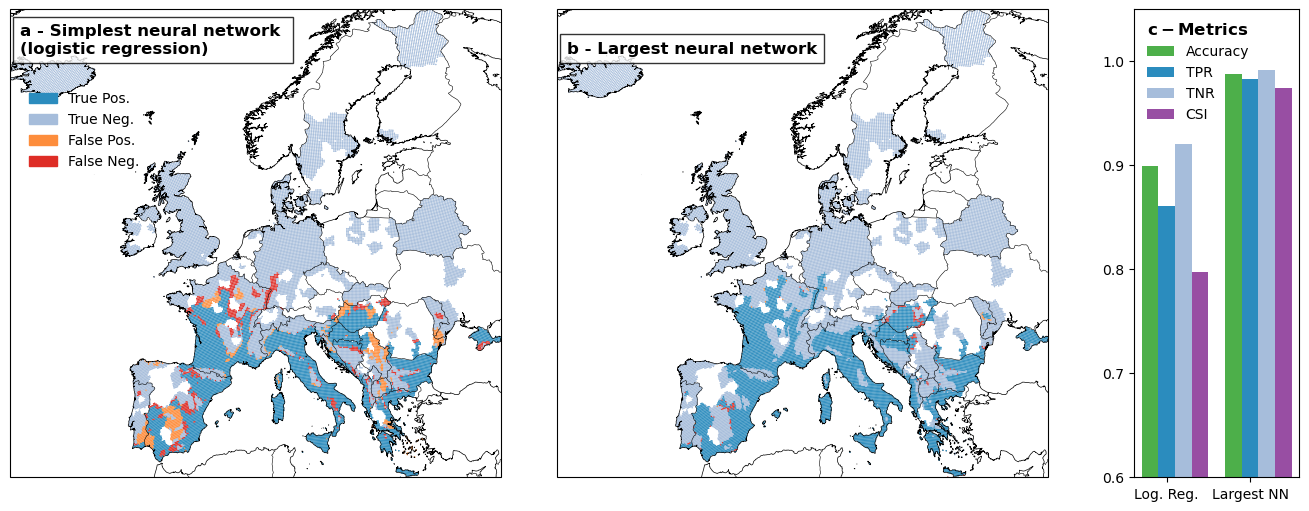

In [33]:
import geopandas as gpd
import matplotlib.pyplot as plt
#import contextily as ctx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np

df_Presence_Absence = gpd.GeoDataFrame(df_Presence_Absence.copy(), geometry='geometry', crs='EPSG:4326')
#minx, miny, maxx, maxy = df_Presence_Absence.total_bounds


def plot_map(df_, ax, markersize=10, marker='.', alpha=1, title=None):
    categories = ['True Pos.', 'True Neg.', 'False Pos.', 'False Neg.']
    colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
    colormap = ListedColormap(colors)

    # Do NOT reproject!
    df_sampled = df_.copy()

    # Sanity check for geometry
    df_sampled = df_sampled[df_sampled.geometry.is_valid]
    minx, miny, maxx, maxy = df_sampled.total_bounds
    df_sampled['results'] = np.select(
        [
            (df_sampled['Presence_Absence'] == 1) & (df_sampled['predicted'] == 1),
            (df_sampled['Presence_Absence'] == 0) & (df_sampled['predicted'] == 0),
            (df_sampled['Presence_Absence'] == 0) & (df_sampled['predicted'] == 1),
            (df_sampled['Presence_Absence'] == 1) & (df_sampled['predicted'] == 0),
        ],
        categories,
        default='NA'  # Add a string default value
    )
    df_sampled['results'] = pd.Categorical(df_sampled['results'], categories=categories)

    print("Plotting map with extent:", [minx, maxx, miny, maxy])
    ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')

    df_sampled.plot(
        'results',
        markersize=markersize,
        ax=ax,
        #marker=marker,
        cmap=colormap,
        legend=False,
        edgecolor='none',
        transform=ccrs.PlateCarree(),
        alpha=alpha,
        #set legend position and title
        legend_kwds={'loc': 'upper left', 
                     'title': title}
    )
    return ax

fig = plt.figure(figsize=(13, 5), constrained_layout=True)
#fig.suptitle('Predicted Risk Areas for Aedes Albopictus', fontsize=16, fontweight='bold')

gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 1], wspace=0.12)
axes = [fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree()) for i in range(2)]
ax_bar = fig.add_subplot(gs[0, 2])

all_df_res = []
def pred_str(true, pred):
    return 'True Pos.' if true == 1 and pred == 1 else 'True Neg.' if true == 0 and pred == 0 else 'False Neg.' if true == 1 and pred == 0 else 'False Pos.'



accs = {}
model_info = res_df[res_df["hidden_layers"] == "[]"]
net_ = model_info["model"].values[0][0]
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5
df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)
plot_map(df_temp, axes[0], markersize=1, marker='.', alpha=0.8, title='No Hidden Layers \n(Logistic Regression)')
accs["[]"] = model_info["MEAN_ACC_test"].values[0]
#axes[0].legend(loc='upper left', fontsize=8, markerscale=2, title='Results', title_fontsize='10', frameon=False)


model_info = res_df[res_df["hidden_layers"] == "[50, 50, 50]"]
net_ = model_info["model"].values[0][0]
df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5
df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)
plot_map(df_temp, axes[1], markersize=1, marker='.', alpha=0.8, title='[50,50,50] Hidden Layers \n(Neural Network)')
accs["[50, 50, 50]"] = model_info["MEAN_ACC_test"].values[0]

# Bar plot for accuracy, TPR, TNR, and CSI
x_labels = ['Log. Reg.', 'Largest NN']
x = np.arange(len(x_labels))  # the label locations
width = 0.2  # the width of the bars

# Values for each metric
accuracy_values = np.array(list(accs.values())) / 100
tpr_values = [res_df[res_df["hidden_layers"] == "[]"]["MEAN_TPR_test"].values[0], model_info["MEAN_TPR_test"].values[0]]
tnr_values = [res_df[res_df["hidden_layers"] == "[]"]["MEAN_TNR_test"].values[0], model_info["MEAN_TNR_test"].values[0]]
csi_values = [res_df[res_df["hidden_layers"] == "[]"]["CSI_test"].values[0], model_info["CSI_test"].values[0]]

# Plot each metric with a distinct color palette
ax_bar.bar(x - width, accuracy_values, width, label='Accuracy', color="#4daf4a")  # Green
ax_bar.bar(x, tpr_values, width, label='TPR', color='#2b8cbe')  # Blue
ax_bar.bar(x + width, tnr_values, width, label='TNR', color='#a6bddb')  # light blue
ax_bar.bar(x + 2 * width, csi_values, width, label='CSI', color="#984ea3")  # Purple

# Formatting the bar plot
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(x_labels)
ax_bar.set_ylim(0.60, 1.05)
#ax_bar.set_ylabel('Metrics')
ax_bar.legend(loc='upper left', fontsize=10, frameon=False, title=r'$\bf{c - Metrics}$', title_fontsize='12')

# After plotting both maps and the bar:
import matplotlib.patches as mpatches
categories = ['True Pos.', 'True Neg.', 'False Pos.', 'False Neg.']
colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
patches = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, categories)]
fig.legend(handles=patches, bbox_to_anchor=(.01, 0.75), loc='center left', frameon=False, fontsize=10)

# Panel "a"
axes[0].text(
    0.02, 0.9, "a - Simplest neural network \n(logistic regression)",
    transform=axes[0].transAxes,
    fontsize=12, fontweight='bold', va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)

# Panel "b"
axes[1].text(
    0.02, 0.9, "b - Largest neural network",
    transform=axes[1].transAxes,
    fontsize=12, fontweight='bold', va='bottom', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=5)
)
for spine in ax.spines.values():
    spine.set_visible(False)


fig.savefig(f"./comparison_lr_nn.png", dpi=400)

plt.show()

In [ ]:
csi_values

: 